In [53]:
%pip install xgboost lightgbm catboost -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import joblib
import gc
import optuna
import warnings

from data_loader import load_data_csv
from data_processor import get_features, clean_text
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import SGDClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

In [1]:
#data_loader.py
import pandas as pd
import os

#Loading .csv
def load_data_csv(path):
    cols = ["target", "ids", "date", "flag", "user", "text"]
    if not os.path.exists(path):
        print(f'Файл не найден, путь {path} неверный.')
        return None
    try:
        print('Файл успешно загружен')
        return pd.read_csv('training.1600000.processed.noemoticon.csv', 
                 encoding='latin-1', 
                 names=cols)
    except Exception as e:
        print(f'Возникла ошибка {e} при загрузке файла')
        return None

def describe_data(df):
    print(df.describe(include = "all"))
    print(df.shape)
    print(df.info())
    print(f'Missing data:\n{df.isnull().sum()}')
    print(f'Список столбцов с пропущенными значениями: {df.columns[df.isnull().any()].tolist()}')

In [56]:
# data_processor.py
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english'))

eyes = r'[:;=]'
nose = r'-?'
happy_pattern = rf'({eyes}{nose}[D\)P\]])|(\){nose}{eyes})'
sad_pattern = rf'({eyes}{nose}[\(\[S\|])|([\[\(\|SD]{nose}{eyes})'

happy_re = re.compile(happy_pattern)
sad_re = re.compile(sad_pattern)


def get_features(text: str) -> tuple[int, int, int, int, int, int]:
    """
    Извлечь признаки из сырого (неочищенного) текста.
    Необходимо вызвать перед clean_text(), чтобы сохранить заглавные буквы, пунктуацию и эмодзи.
    """
    if not isinstance(text, str):
        return 0, 0, 0, 0, 0, 0

    char_count = len(text)

    words = text.split()
    word_count = len(words)

    is_caps = len([w for w in words if w.isupper() and len(w) > 2])

    excl_count = text.count('!')

    h = 1 if happy_re.search(text) else 0
    s = 1 if sad_re.search(text) else 0

    return h, s, char_count, word_count, is_caps, excl_count


def clean_text(text: str) -> str:
    """
    Очистить и нормализовать текст для подачи на вход модели.
    Вызовите get_features() для сырого текста ПЕРЕД этой функцией.
    """
    if not isinstance(text, str):  # ← Explicit guard instead of silent failure
        return ""

    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)

    words = text.split()
    cleaned_words = [w for w in words if w not in stop_words]

    return " ".join(cleaned_words)

In [57]:
# Загрузка данных
df = load_data_csv('training.1600000.processed.noemoticon.csv')

if df is not None:
    print('--- Данные загружены ---')

    # Замена 4 → 1 в target
    df['target'] = df['target'].replace(4, 1)
    assert set(df['target'].unique()).issubset({0, 1}), "target содержит неожиданные значения"

    # Сэмпл 400к
    df = pd.concat([
        df[df['target'] == 0].sample(200000, random_state=42),
        df[df['target'] == 1].sample(200000, random_state=42)
    ]).reset_index(drop=True)
    print(f"Размер после сэмпла: {df.shape}")

    describe_data(df)

    NUMERIC_COLS = ['has_happy', 'has_sad', 'char_count', 'word_count', 'is_caps', 'excl_count']

    # Извлечение признаков — на сыром тексте до очистки
    print("\nИзвлечение признаков...")
    results = [get_features(t) for t in df['text']]
    features_df = pd.DataFrame(results, columns=NUMERIC_COLS, index=df.index)  # ← убрали feature_cols
    assert features_df.shape == (len(df), len(NUMERIC_COLS)), "Mismatch in feature extraction"
    df[NUMERIC_COLS] = features_df
    print('Признаки извлечены:')
    print(df[NUMERIC_COLS].head())

    # Очистка текста
    print("\nОчистка текста...")
    df['cleaned_text'] = df['text'].apply(clean_text)
    print('Текст очищен:')
    print(df[['text', 'cleaned_text']].head())

else:
    print('Ошибка в загрузке данных')

Файл успешно загружен
--- Данные загружены ---
Размер после сэмпла: (400000, 6)
               target           ids                          date      flag  \
count   400000.000000  4.000000e+05                        400000    400000   
unique            NaN           NaN                        312244         1   
top               NaN           NaN  Mon Jun 01 14:18:34 PDT 2009  NO_QUERY   
freq              NaN           NaN                             8    400000   
mean         0.500000  1.999119e+09                           NaN       NaN   
std          0.500001  1.932242e+08                           NaN       NaN   
min          0.000000  1.467810e+09                           NaN       NaN   
25%          0.000000  1.957017e+09                           NaN       NaN   
50%          0.500000  2.002142e+09                           NaN       NaN   
75%          1.000000  2.177052e+09                           NaN       NaN   
max          1.000000  2.329205e+09                

target
0    1500
1    1500
Name: count, dtype: int64


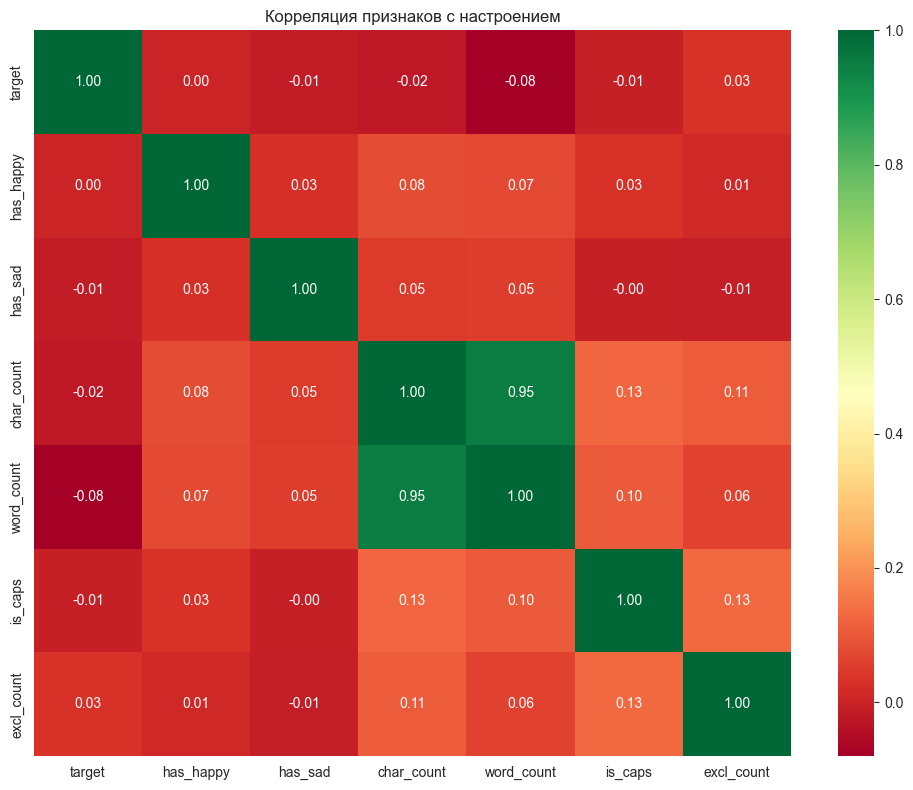

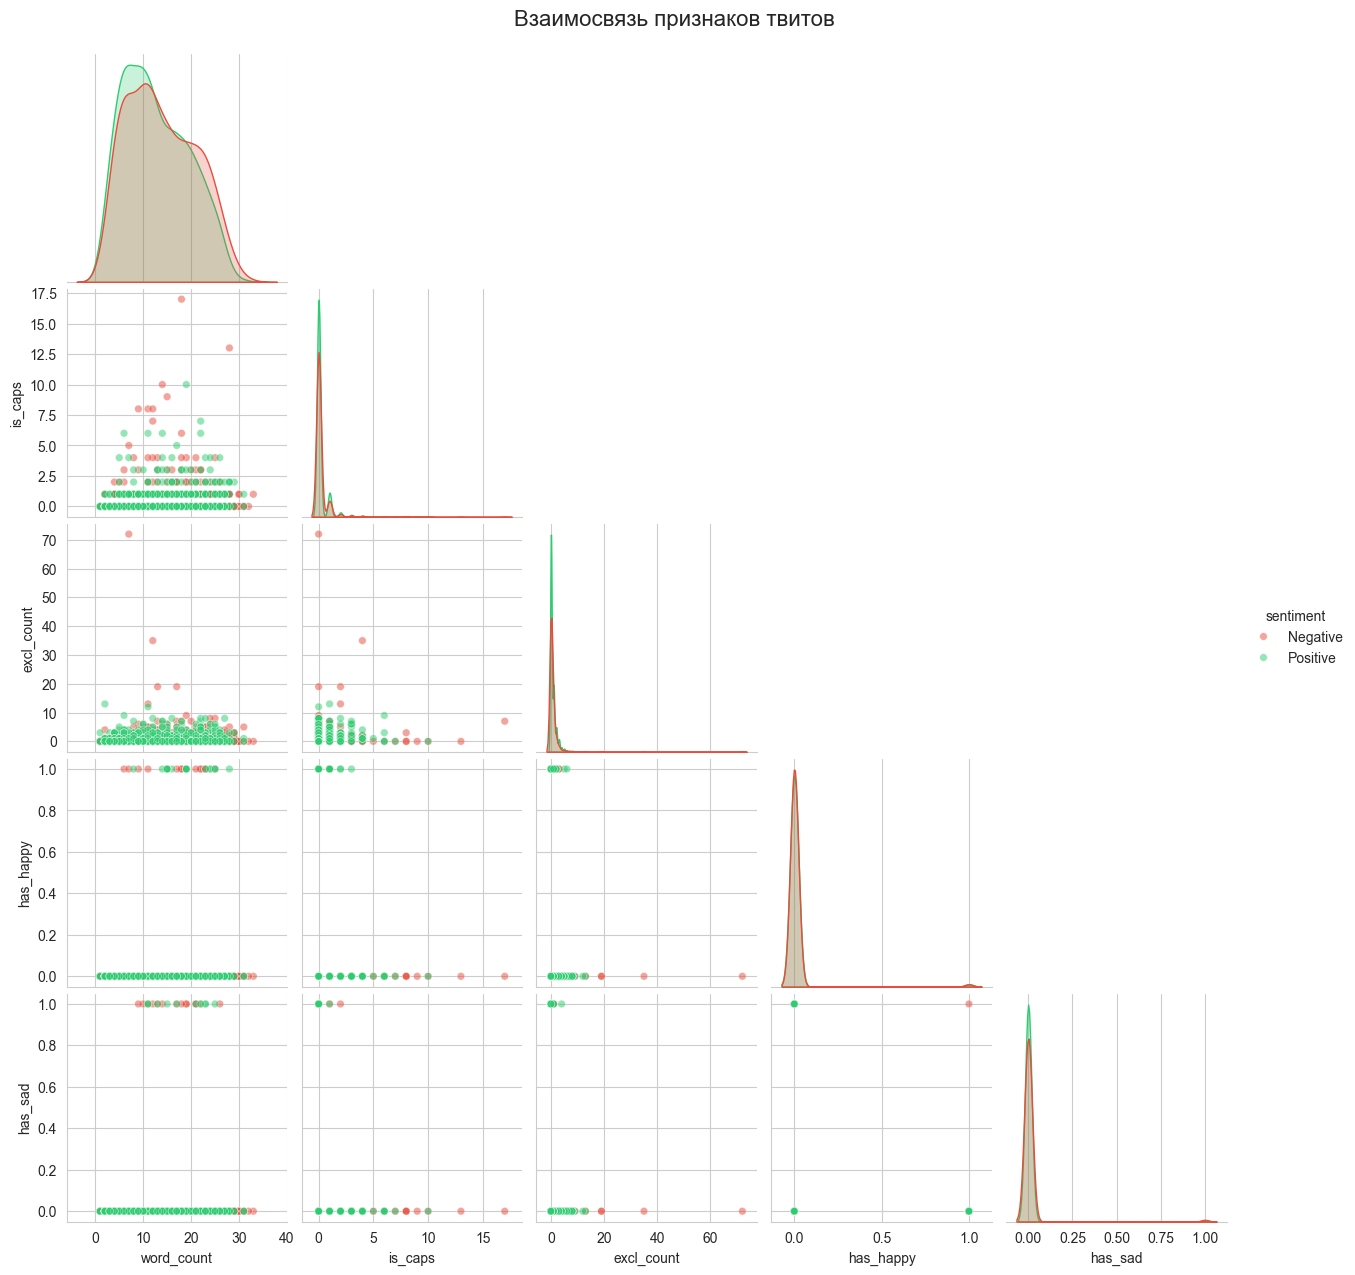

In [58]:
# визуализация и предварительный анализ
sns.set_style("whitegrid")
sns.set_palette("rocket")

assert set(df['target'].unique()).issubset({0, 1}), \
    "target содержит значения кроме 0/1 — замените 4 → 1 перед визуализацией"

SENTIMENT_MAP = {0: 'Negative', 1: 'Positive'}
PALETTE = {'Positive': '#2ecc71', 'Negative': '#e74c3c'}

# Стратифицированная выборка
df_sample = pd.concat([
    df[df['target'] == 0].sample(1500, random_state=42),
    df[df['target'] == 1].sample(1500, random_state=42)
]).reset_index(drop=True)
df_sample['sentiment'] = df_sample['target'].map(SENTIMENT_MAP)
print(df_sample['target'].value_counts())

# --- График 1: Тепловая карта корреляций ---
plt.figure(figsize=(10, 8))
features_to_corr = ['target'] + NUMERIC_COLS  # ← убрали дублирование списка
sns.heatmap(df_sample[features_to_corr].corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Корреляция признаков с настроением')
plt.tight_layout()
plt.show()

# --- График 2: Pairplot ---
cols_to_plot = ['word_count', 'is_caps', 'excl_count', 'has_happy', 'has_sad', 'sentiment']
g = sns.pairplot(
    df_sample[cols_to_plot],
    hue='sentiment',
    palette=PALETTE,
    diag_kind='kde',
    plot_kws={'alpha': 0.5, 's': 30, 'edgecolor': 'w'},
    corner=True
)
g.fig.suptitle('Взаимосвязь признаков твитов', y=1.02, fontsize=16)
plt.show()

In [59]:
# CatBoostClassifier подбор параметров
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

# --- 1. Данные для CatBoost ---
FEATURE_COLS_CAT = NUMERIC_COLS + ['cleaned_text']

# Подвыборка для тюнинга
X_tune_cat = df[FEATURE_COLS_CAT]
y_tune_cat = df['target'].values

X_tune_cat, _, y_tune_cat, _ = train_test_split(
    X_tune_cat, y_tune_cat, train_size=30000, stratify=y_tune_cat, random_state=42
)

def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 100, 300),
        'depth': trial.suggest_int('depth', 4, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),
        'random_strength': trial.suggest_float('random_strength', 0, 1),
    }

    skf = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)
    scores = []

    for train_idx, val_idx in skf.split(X_tune_cat, y_tune_cat):
        X_tr = X_tune_cat.iloc[train_idx]
        X_val = X_tune_cat.iloc[val_idx]
        y_tr = y_tune_cat[train_idx]
        y_val = y_tune_cat[val_idx]

        model = CatBoostClassifier(
            **params,
            text_features=['cleaned_text'],
            task_type="CPU",
            verbose=False,
            random_seed=42
        )
        model.fit(X_tr, y_tr)
        scores.append(accuracy_score(y_val, model.predict(X_val)))

    return np.mean(scores)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10, n_jobs=4, show_progress_bar=True)
best_params_cat = study.best_params
print(f"Лучшие параметры: {best_params_cat}")

Best trial: 6. Best value: 0.748733: 100%|██████████| 10/10 [14:10<00:00, 85.08s/it]

Лучшие параметры: {'iterations': 195, 'depth': 8, 'learning_rate': 0.260459502890254, 'l2_leaf_reg': 7.112809154791617, 'bagging_temperature': 0.414469319257908, 'random_strength': 0.9893593831380961}


In [60]:
# CatBoostClassifier — финальное обучение
X_cat = df[FEATURE_COLS_CAT]
y = df['target'].values

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cat, y, test_size=0.2, random_state=42, stratify=y
)

# 1. Финальная модель
final_model = CatBoostClassifier(
    **best_params_cat,
    text_features=['cleaned_text'],
    task_type="CPU",
    verbose=100,
    random_seed=42
)

# 2. Обучение
start_time = time.time()
print("Обучаем финальный CatBoost...")
final_model.fit(X_train_c, y_train_c)
print(f"Время обучения: {time.time() - start_time:.2f} сек")

# 3. Сохранение
final_model.save_model('catboost_final.cbm')
print("Модель сохранена: catboost_final.cbm")

# 4. Метрики
y_pred_c = final_model.predict(X_test_c)
print(f"Accuracy: {accuracy_score(y_test_c, y_pred_c):.4f}")
print(classification_report(y_test_c, y_pred_c, target_names=['Negative', 'Positive']))

Обучаем финальный CatBoost...
0:	learn: 0.6229476	total: 749ms	remaining: 2m 25s
100:	learn: 0.4751832	total: 1m 15s	remaining: 1m 10s
194:	learn: 0.4663462	total: 2m 31s	remaining: 0us
Время обучения: 159.27 сек
Модель сохранена: catboost_final.cbm
Accuracy: 0.7803
              precision    recall  f1-score   support

    Negative       0.78      0.77      0.78     40000
    Positive       0.78      0.79      0.78     40000

    accuracy                           0.78     80000
   macro avg       0.78      0.78      0.78     80000
weighted avg       0.78      0.78      0.78     80000



In [61]:
# TF-IDF векторизация: преобразование текста в числовую матрицу признаков
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
)

print("Превращаем текст в векторы...")
X_tfidf = tfidf.fit_transform(df['cleaned_text'].values.astype('U'))
additional_features = df[NUMERIC_COLS].values

print(f"X_tfidf: {X_tfidf.shape}")
print(f"Плотность матрицы: {X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1]):.4%}")

joblib.dump(tfidf, 'tfidf.pkl')
print("Векторизатор сохранён")

Превращаем текст в векторы...
X_tfidf: (400000, 50000)
Плотность матрицы: 0.0165%
Векторизатор сохранён


In [64]:
# SVD: сжимаем TF-IDF 50k → 400 признаков
print("Сжимаем пространство признаков (SVD)...")
svd = TruncatedSVD(n_components=400, random_state=42)
X_tfidf_reduced = svd.fit_transform(X_tfidf)

del X_tfidf
gc.collect()
print("X_tfidf удалён из памяти")

explained = svd.explained_variance_ratio_.sum()
print(f"Сохранено {explained:.1%} дисперсии")

X_boost = np.hstack([X_tfidf_reduced, additional_features])

del additional_features
gc.collect()

print(f"X_boost: {X_boost.shape}")

joblib.dump(svd, 'svd.pkl')
print("SVD сохранён")

Сжимаем пространство признаков (SVD)...
X_tfidf удалён из памяти
Сохранено 25.6% дисперсии
X_boost: (400000, 406)
SVD сохранён


In [65]:
# LightGBM — подбор параметров
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

X_tune_lgb, _, y_tune_lgb, _ = train_test_split(
    X_boost, y, train_size=20000, stratify=y, random_state=42
)

def objective_lgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'num_leaves': trial.suggest_int('num_leaves', 31, 127),
        'max_depth': trial.suggest_int('max_depth', 5, 20),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 100),
        'subsample': trial.suggest_float('subsample', 0.7, 1.0),
    }

    model = LGBMClassifier(
        **params,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    score = cross_val_score(
        model, X_tune_lgb, y_tune_lgb,
        cv=2, scoring='accuracy', n_jobs=-1
    ).mean()

    return score

study_lgb = optuna.create_study(direction='maximize')
study_lgb.optimize(objective_lgb, n_trials=10, n_jobs=2, show_progress_bar=True)

best_params_lgb = study_lgb.best_params
print(f"Лучшие параметры: {best_params_lgb}")

# Финальный сплит
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_boost, y, test_size=0.2, random_state=42, stratify=y
)

Best trial: 4. Best value: 0.7153: 100%|██████████| 10/10 [07:41<00:00, 46.14s/it]


Лучшие параметры: {'n_estimators': 218, 'learning_rate': 0.09148888965089097, 'num_leaves': 57, 'max_depth': 14, 'min_child_samples': 27, 'subsample': 0.9778302911572185}


In [66]:
# LightGBM — финальное обучение

# 1. Финальная модель
lgbm_final = LGBMClassifier(
    **best_params_lgb,
    n_jobs=-1,
    random_state=42,
    verbose=-1
)

# 2. Обучение
start_time = time.time()
print("Обучаем LightGBM на сжатых данных...")
lgbm_final.fit(X_train_b, y_train_b)
print(f"Время обучения: {time.time() - start_time:.2f} сек")

# 3. Сохранение
lgbm_final.booster_.save_model('lgbm_sentiment.txt')
print("Модель сохранена: lgbm_sentiment.txt")

# 4. Метрики
y_pred_lgbm = lgbm_final.predict(X_test_b)
print(f"Accuracy: {accuracy_score(y_test_b, y_pred_lgbm):.4f}")
print(classification_report(y_test_b, y_pred_lgbm, target_names=['Negative', 'Positive']))

Обучаем LightGBM на сжатых данных...
Время обучения: 115.18 сек
Модель сохранена: lgbm_sentiment.txt
Accuracy: 0.7490
              precision    recall  f1-score   support

    Negative       0.76      0.74      0.75     40000
    Positive       0.74      0.76      0.75     40000

    accuracy                           0.75     80000
   macro avg       0.75      0.75      0.75     80000
weighted avg       0.75      0.75      0.75     80000



In [67]:
# XGBoost — подбор параметров
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

X_tune_xgb, _, y_tune_xgb, _ = train_test_split(
    X_boost, y, train_size=20000, stratify=y, random_state=42
)

def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'max_depth': trial.suggest_int('max_depth', 4, 8),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 0.3),
    }

    model = XGBClassifier(
        **params,
        random_state=42,
        n_jobs=-1,
        verbosity=0,
        eval_metric='logloss'
    )

    score = cross_val_score(
        model, X_tune_xgb, y_tune_xgb,
        cv=2, scoring='accuracy', n_jobs=-1
    ).mean()

    return score

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=10, n_jobs=2, show_progress_bar=True)

best_params_xgb = study_xgb.best_params
print(f"Лучшие параметры: {best_params_xgb}")

# Финальный сплит
X_train_x, X_test_x, y_train_x, y_test_x = train_test_split(
    X_boost, y, test_size=0.2, random_state=42, stratify=y
)

Best trial: 3. Best value: 0.714: 100%|██████████| 10/10 [03:32<00:00, 21.20s/it] 


Лучшие параметры: {'n_estimators': 271, 'learning_rate': 0.06750202286115081, 'max_depth': 8, 'min_child_weight': 3, 'subsample': 0.8696452638907232, 'colsample_bytree': 0.8020525726520076, 'gamma': 0.098469854992337}


In [68]:
# XGBoost — финальное обучение

# --- 1. Финальная модель ---
xgb_final = XGBClassifier(
    **best_params_xgb,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
    eval_metric='logloss'
)

# --- 2. Обучение ---
start_time = time.time()
print("Обучаем XGBoost на сжатых данных...")
xgb_final.fit(X_train_x, y_train_x)
print(f"Время обучения: {time.time() - start_time:.2f} сек")

# --- 3. Сохранение ---
xgb_final.save_model('xgb_sentiment.json')
print("Модель сохранена: xgb_sentiment.json")

# --- 4. Метрики ---
y_pred_xgb = xgb_final.predict(X_test_x)
print(f"Accuracy: {accuracy_score(y_test_x, y_pred_xgb):.4f}")
print(classification_report(y_test_x, y_pred_xgb, target_names=['Negative', 'Positive']))

Обучаем XGBoost на сжатых данных...
Время обучения: 214.69 сек
Модель сохранена: xgb_sentiment.json
Accuracy: 0.7485
              precision    recall  f1-score   support

    Negative       0.75      0.74      0.75     40000
    Positive       0.74      0.76      0.75     40000

    accuracy                           0.75     80000
   macro avg       0.75      0.75      0.75     80000
weighted avg       0.75      0.75      0.75     80000



In [69]:
# Linear SVM (SGD) — подбор параметров
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

scaler = StandardScaler()
additional_features_scaled = scaler.fit_transform(df[NUMERIC_COLS].values)

joblib.dump(scaler, 'scaler.pkl')

X_boost_scal = np.hstack([X_tfidf_reduced, additional_features_scaled])

X_tune_sgd, _, y_tune_sgd, _ = train_test_split(
    X_boost_scal, y, train_size=20000, stratify=y, random_state=42
)

def objective_sgd(trial):
    params = {
        'alpha': trial.suggest_float('alpha', 1e-5, 1e-2, log=True),
        'loss': trial.suggest_categorical('loss', ['hinge', 'modified_huber']),
        'penalty': trial.suggest_categorical('penalty', ['l2', 'l1', 'elasticnet']),
        'learning_rate': trial.suggest_categorical('learning_rate', ['optimal', 'adaptive']),
        'max_iter': trial.suggest_int('max_iter', 100, 300),
    }

    model = SGDClassifier(
        **params,
        random_state=42,
        n_jobs=-1,
        early_stopping=True,
        validation_fraction=0.1
    )

    score = cross_val_score(
        model, X_tune_sgd, y_tune_sgd,
        cv=2, scoring='accuracy', n_jobs=-1
    ).mean()

    return score

study_sgd = optuna.create_study(direction='maximize')
study_sgd.optimize(objective_sgd, n_trials=10, n_jobs=2, show_progress_bar=True)

best_params_sgd = study_sgd.best_params
print(f"Лучшие параметры: {best_params_sgd}")

# Финальный сплит
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_boost_scal, y, test_size=0.2, random_state=42, stratify=y
)

Best trial: 8. Best value: 0.7247: 100%|██████████| 10/10 [00:21<00:00,  2.14s/it]


Лучшие параметры: {'alpha': 4.300337395380911e-05, 'loss': 'modified_huber', 'penalty': 'elasticnet', 'learning_rate': 'adaptive', 'max_iter': 177}


In [70]:
# Linear SVM (SGD) — финальное обучение

# --- 1. Финальная модель ---
sgd_final = SGDClassifier(
    **best_params_sgd,
    random_state=42,
    n_jobs=-1,
    early_stopping=True,
    validation_fraction=0.1
)

# --- 2. Обучение ---
start_time = time.time()
print("Обучаем Linear SVM (SGD) на сжатых данных...")
sgd_final.fit(X_train_s, y_train_s)
print(f"Время обучения: {time.time() - start_time:.2f} сек")

# --- 3. Сохранение ---
joblib.dump(sgd_final, 'sgd_sentiment.pkl')
print("Модель сохранена: sgd_sentiment.pkl")

# --- 4. Метрики ---
y_pred_svm = sgd_final.predict(X_test_s)
print(f"Accuracy: {accuracy_score(y_test_s, y_pred_svm):.4f}")
print(classification_report(y_test_s, y_pred_svm, target_names=['Negative', 'Positive']))

Обучаем Linear SVM (SGD) на сжатых данных...
Время обучения: 42.98 сек
Модель сохранена: sgd_sentiment.pkl
Accuracy: 0.7397
              precision    recall  f1-score   support

    Negative       0.76      0.71      0.73     40000
    Positive       0.73      0.77      0.75     40000

    accuracy                           0.74     80000
   macro avg       0.74      0.74      0.74     80000
weighted avg       0.74      0.74      0.74     80000



In [71]:
# Decision Tree — подбор параметров
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

X_tune_dt, _, y_tune_dt, _ = train_test_split(
    X_boost, y, train_size=20000, stratify=y, random_state=42
)

def objective_dt(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 50),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
    }

    model = DecisionTreeClassifier(**params, random_state=42)

    score = cross_val_score(
        model, X_tune_dt, y_tune_dt,
        cv=2, scoring='accuracy', n_jobs=-1
    ).mean()

    return score

study_dt = optuna.create_study(direction='maximize')
study_dt.optimize(objective_dt, n_trials=10, n_jobs=2, show_progress_bar=True)

best_params_dt = study_dt.best_params
print(f"Лучшие параметры: {best_params_dt}")

# Финальный сплит
X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(
    X_boost, y, test_size=0.2, random_state=42, stratify=y
)

Best trial: 8. Best value: 0.6325: 100%|██████████| 10/10 [00:41<00:00,  4.18s/it]


Лучшие параметры: {'max_depth': 7, 'min_samples_split': 3, 'min_samples_leaf': 2, 'criterion': 'entropy'}


In [72]:
# Decision Tree — финальное обучение

# 1. Финальная модель
dt_final = DecisionTreeClassifier(**best_params_dt, random_state=42)

# 2. Обучение
start_time = time.time()
print("Обучаем Decision Tree...")
dt_final.fit(X_train_dt, y_train_dt)
print(f"Время обучения: {time.time() - start_time:.2f} сек")

# 3. Сохранение
joblib.dump(dt_final, 'dt_sentiment.pkl')
print("Модель сохранена: dt_sentiment.pkl")

# 4. Метрики
y_pred_dt = dt_final.predict(X_test_dt)
print(f"Accuracy: {accuracy_score(y_test_dt, y_pred_dt):.4f}")
print(classification_report(y_test_dt, y_pred_dt, target_names=['Negative', 'Positive']))

Обучаем Decision Tree...
Время обучения: 236.28 сек
Модель сохранена: dt_sentiment.pkl
Accuracy: 0.6507
              precision    recall  f1-score   support

    Negative       0.64      0.70      0.67     40000
    Positive       0.67      0.60      0.63     40000

    accuracy                           0.65     80000
   macro avg       0.65      0.65      0.65     80000
weighted avg       0.65      0.65      0.65     80000



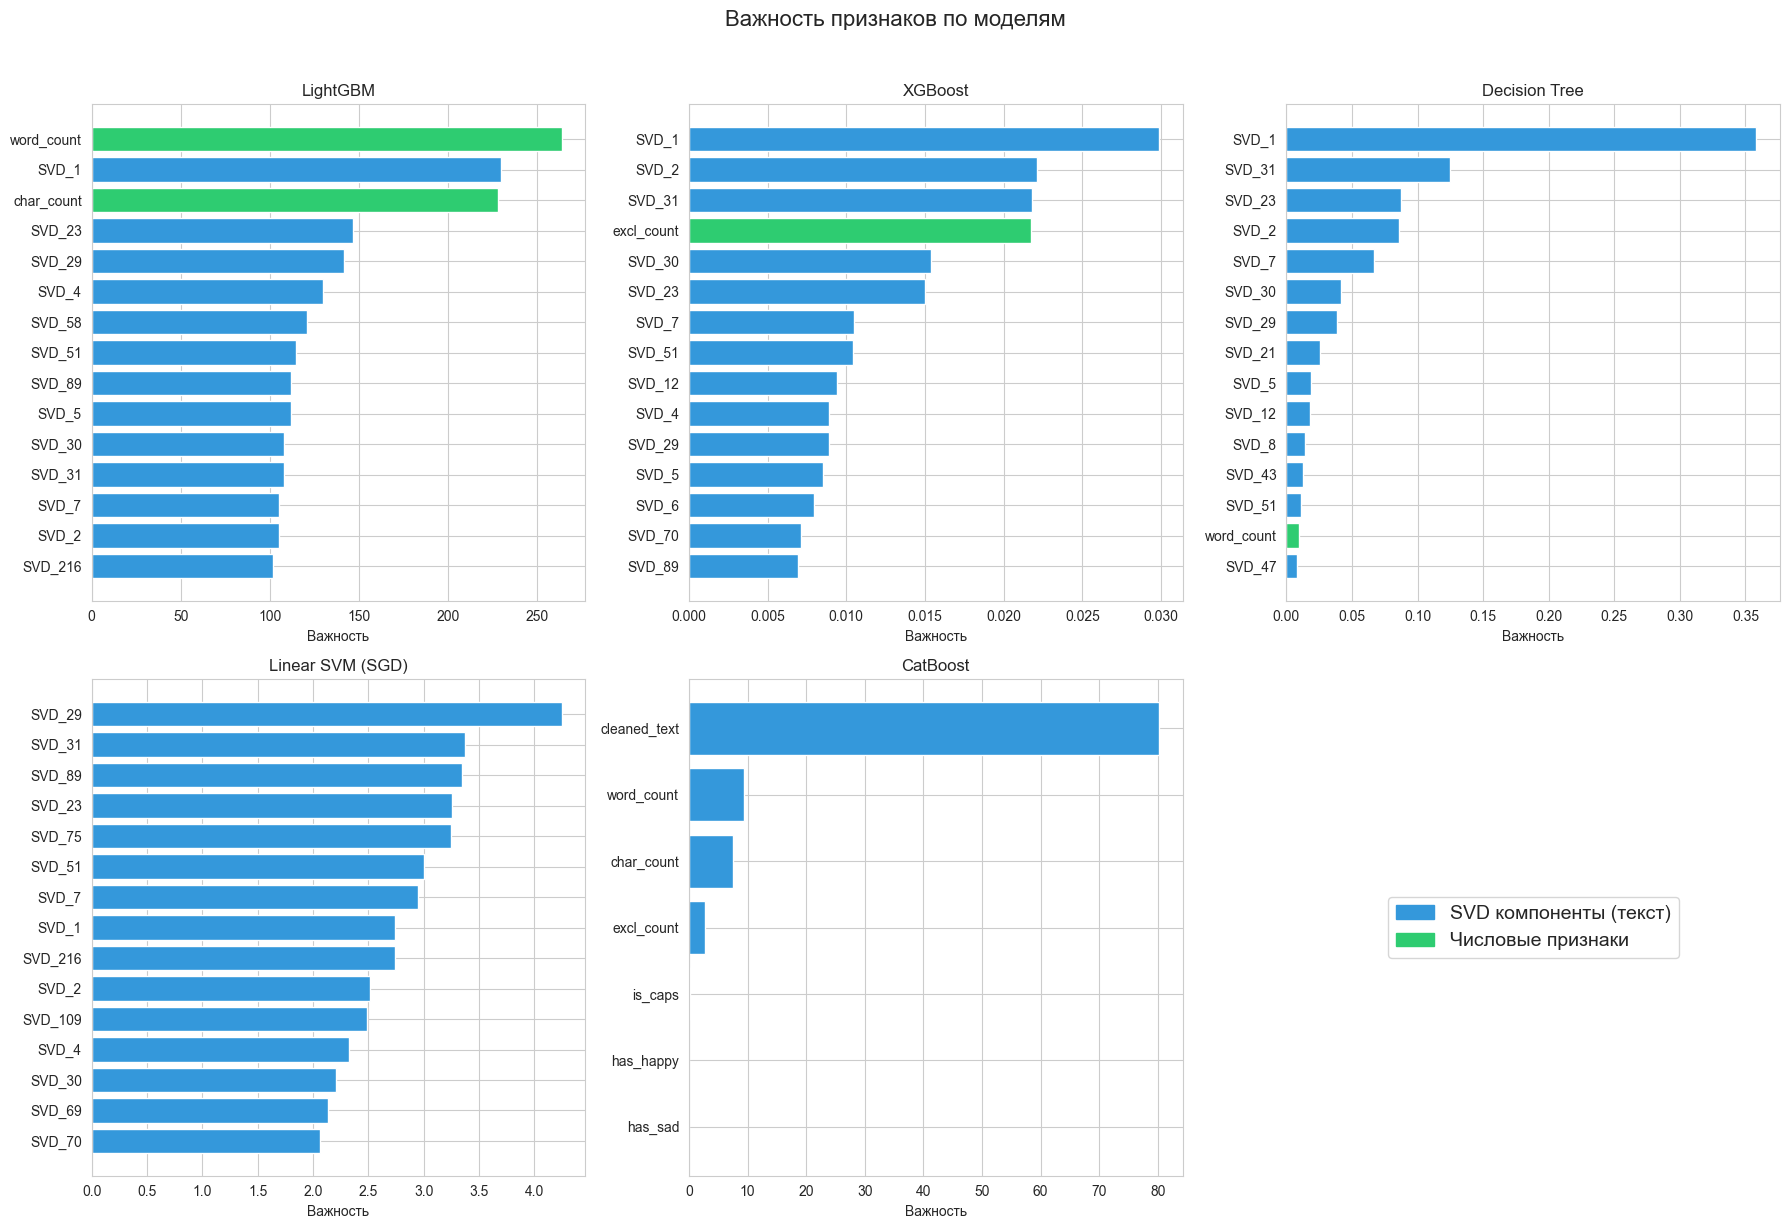

In [73]:
# Важность признаков по моделям
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Важность признаков по моделям', fontsize=16, y=1.02)
axes = axes.flatten()

svd_names = [f'SVD_{i}' for i in range(svd.n_components)]
feature_names = svd_names + NUMERIC_COLS

def plot_top_features(ax, importances, names, title, top_n=15):
    top_n = min(top_n, len(importances))
    indices = np.argsort(importances)[-top_n:]
    colors = ['#2ecc71' if i >= len(svd_names) else '#3498db' for i in indices]
    ax.barh([names[i] for i in indices], importances[indices], color=colors)
    ax.set_title(title)
    ax.set_xlabel('Важность')

# --- LightGBM ---
plot_top_features(axes[0], lgbm_final.feature_importances_, feature_names, 'LightGBM')

# --- XGBoost ---
plot_top_features(axes[1], xgb_final.feature_importances_, feature_names, 'XGBoost')

# --- Decision Tree ---
plot_top_features(axes[2], dt_final.feature_importances_, feature_names, 'Decision Tree')

# --- SGD ---
plot_top_features(axes[3], np.abs(sgd_final.coef_[0]), feature_names, 'Linear SVM (SGD)')

# --- CatBoost — отдельно, свои имена признаков
cat_importances = final_model.get_feature_importance()
cat_feature_names = final_model.feature_names_
plot_top_features(axes[4], cat_importances, cat_feature_names, 'CatBoost')

# --- Легенда ---
axes[5].axis('off')
axes[5].legend(
    handles=[
        plt.Rectangle((0,0),1,1, color='#3498db', label='SVD компоненты (текст)'),
        plt.Rectangle((0,0),1,1, color='#2ecc71', label='Числовые признаки')
    ],
    loc='center', fontsize=14
)

plt.tight_layout()
plt.show()

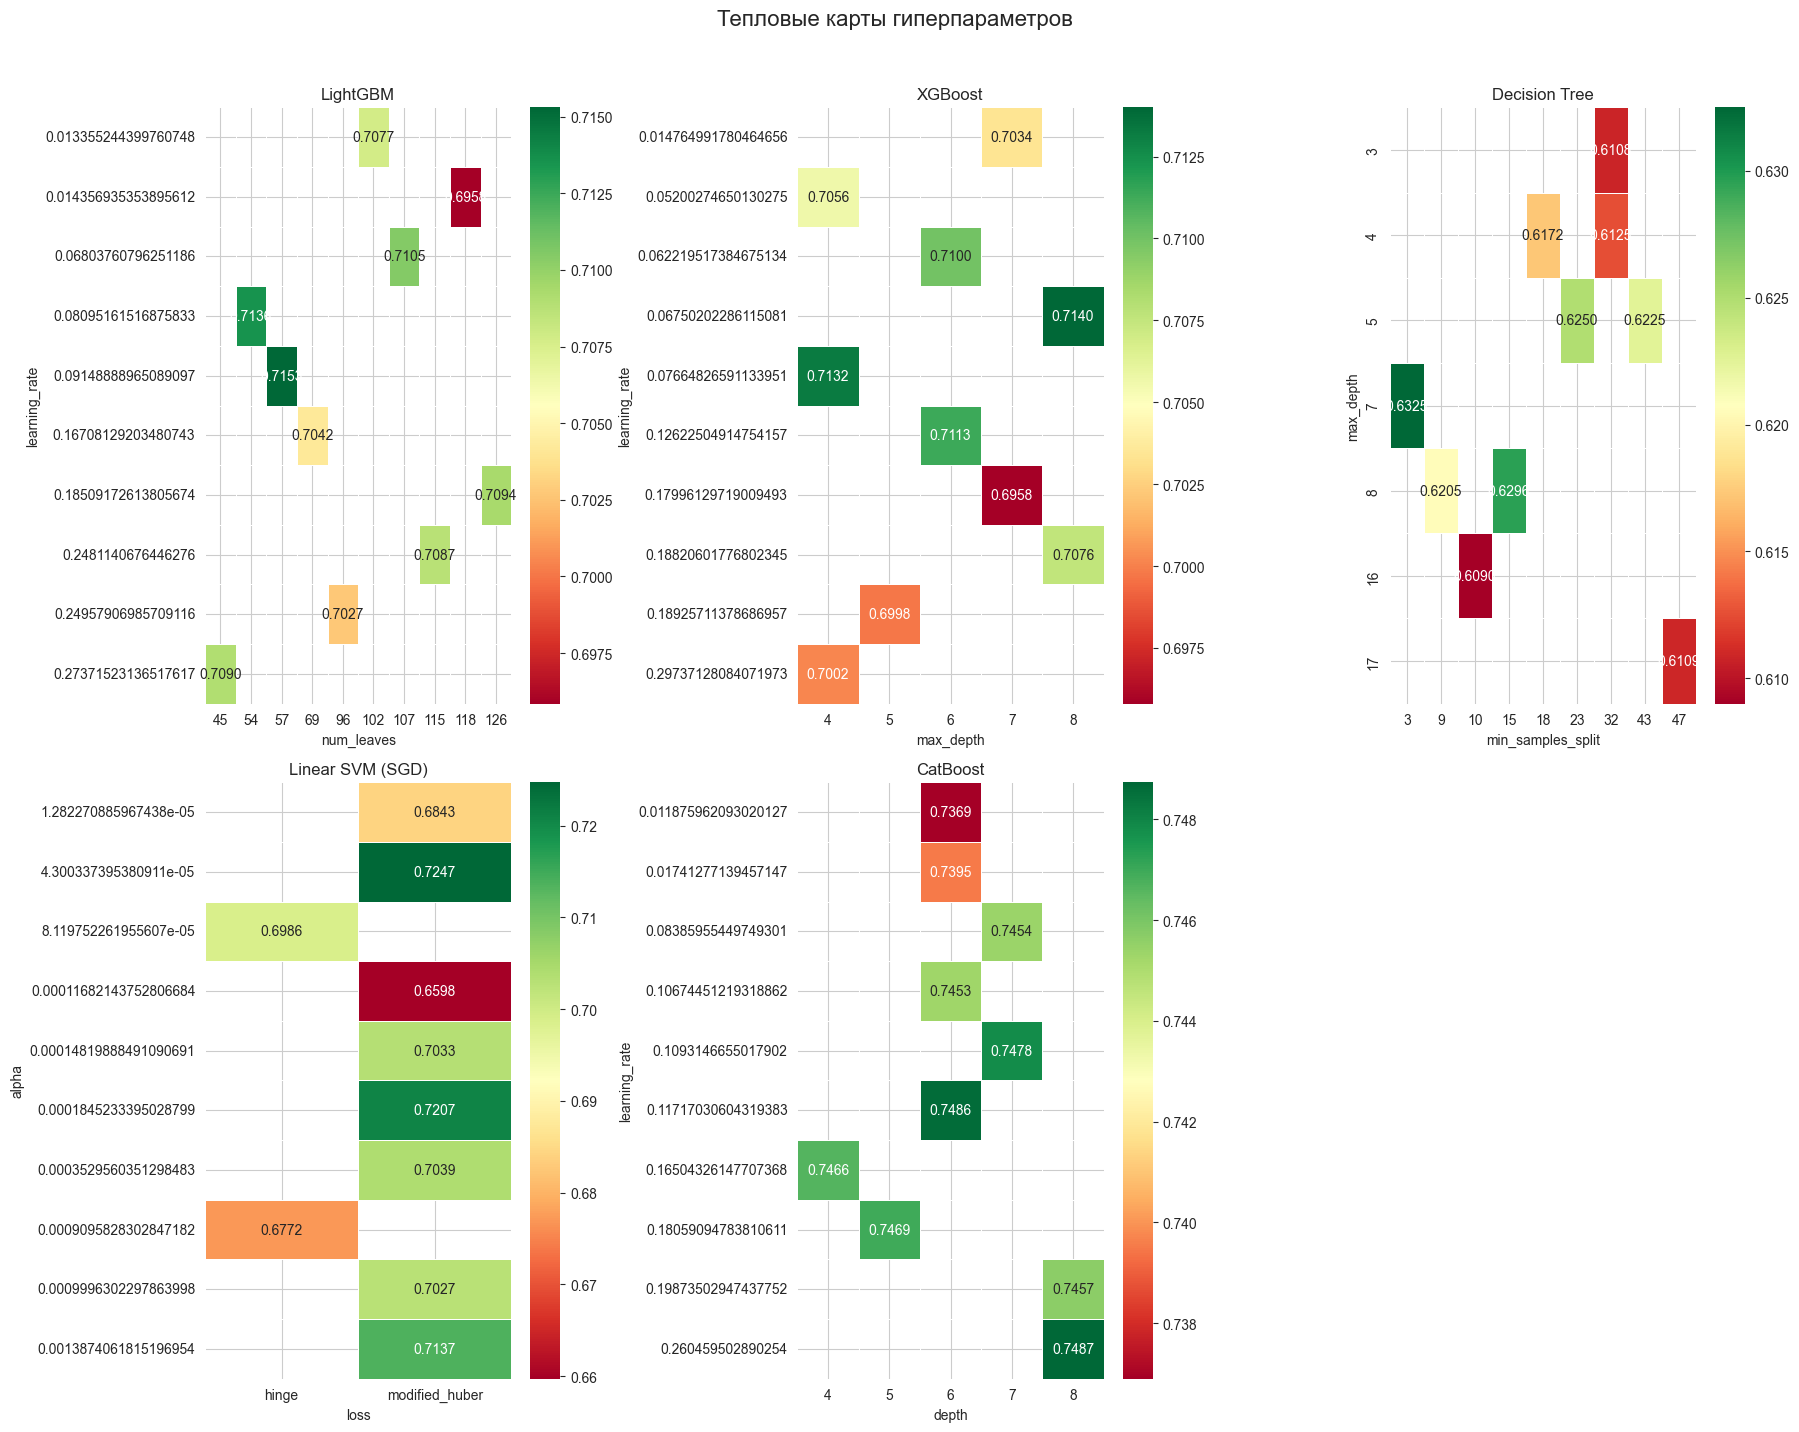

In [74]:
# Тепловые карты гиперпараметров (Optuna)
fig, axes = plt.subplots(2, 3, figsize=(18, 14))
fig.suptitle('Тепловые карты гиперпараметров', fontsize=16, y=1.02)
axes = axes.flatten()

def plot_optuna_heatmap(ax, study, param1, param2, title):
    trials = study.trials_dataframe()
    trials = trials[trials['state'] == 'COMPLETE']
    
    pivot = trials.pivot_table(
        values='value',
        index=f'params_{param1}',
        columns=f'params_{param2}',
        aggfunc='mean'
    )
    if pivot.empty:
        ax.set_title(f'{title}\n(недостаточно данных)')
        ax.axis('off')
        return
    
    sns.heatmap(
        pivot, annot=True, fmt='.4f',
        cmap='RdYlGn', ax=ax,
        linewidths=0.5
    )
    ax.set_title(title)
    ax.set_xlabel(param2)
    ax.set_ylabel(param1)

# --- LightGBM ---
plot_optuna_heatmap(axes[0], study_lgb, 'learning_rate', 'num_leaves', 'LightGBM')

# --- XGBoost ---
plot_optuna_heatmap(axes[1], study_xgb, 'learning_rate', 'max_depth', 'XGBoost')

# --- Decision Tree ---
plot_optuna_heatmap(axes[2], study_dt, 'max_depth', 'min_samples_split', 'Decision Tree')

# --- SGD ---
plot_optuna_heatmap(axes[3], study_sgd, 'alpha', 'loss', 'Linear SVM (SGD)')

# --- CatBoost ---
plot_optuna_heatmap(axes[4], study, 'learning_rate', 'depth', 'CatBoost')

# --- Пустой ---
axes[5].axis('off')

plt.tight_layout()
plt.show()

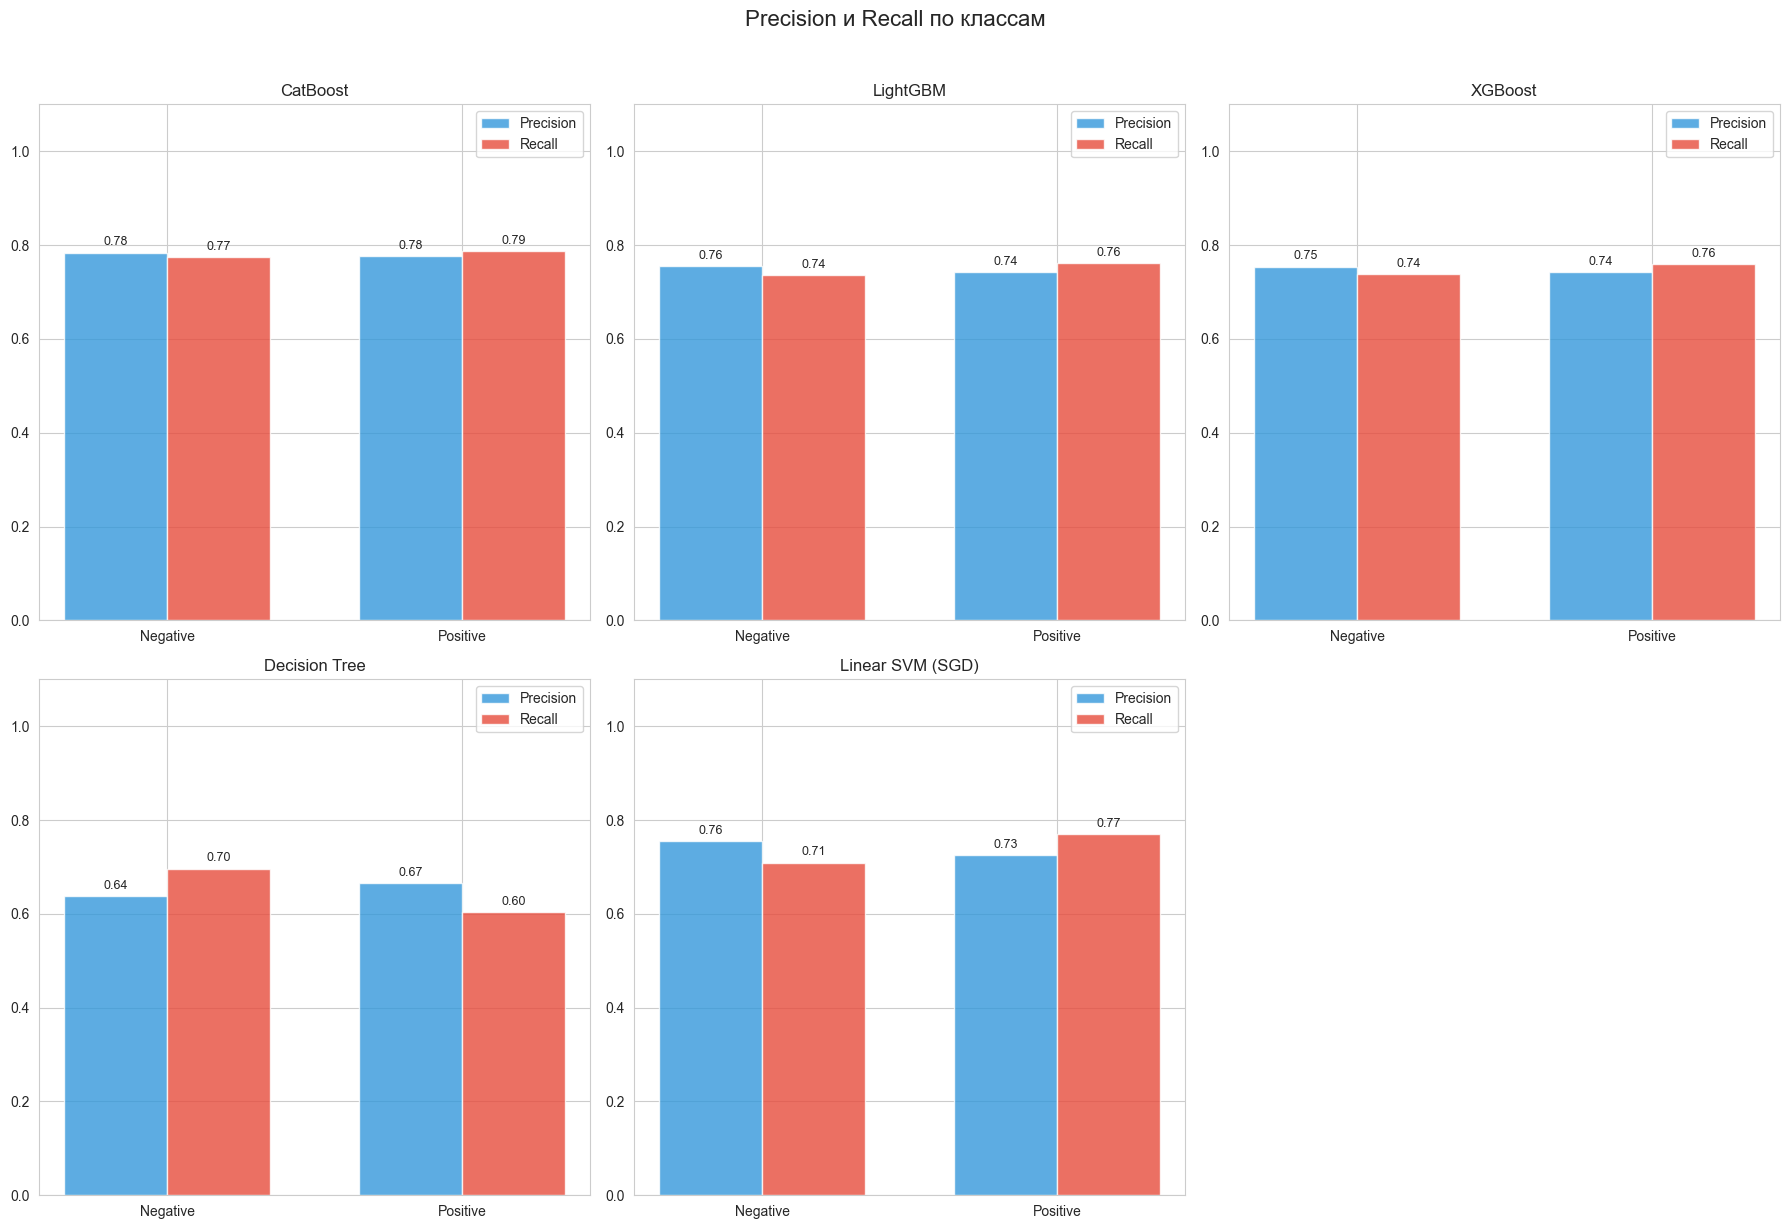

In [77]:
# Precision и Recall по классам

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Precision и Recall по классам', fontsize=16, y=1.02)
axes = axes.flatten()

models = {
    'CatBoost':         (y_test_c, y_pred_c),
    'LightGBM':         (y_test_b, y_pred_lgbm),
    'XGBoost':          (y_test_x, y_pred_xgb),
    'Decision Tree':    (y_test_dt, y_pred_dt),
    'Linear SVM (SGD)': (y_test_s, y_pred_svm),
}

for ax, (name, (y_test, y_pred)) in zip(axes, models.items()):
    report = classification_report(
        y_test, y_pred,
        target_names=['Negative', 'Positive'],
        output_dict=True
    )

    classes = ['Negative', 'Positive']
    precision = [report['Negative']['precision'], report['Positive']['precision']]
    recall = [report['Negative']['recall'], report['Positive']['recall']]
    
    x = np.arange(len(classes))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, precision, width, 
                   label='Precision', color='#3498db', alpha=0.8)
    bars2 = ax.bar(x + width/2, recall, width,
                   label='Recall', color='#e74c3c', alpha=0.8)
    
    ax.set_ylim(0, 1.1)
    ax.set_title(name)
    ax.set_xticks(x)
    ax.set_xticklabels(classes)
    ax.legend()
    ax.bar_label(bars1, fmt='%.2f', padding=3, fontsize=9)
    ax.bar_label(bars2, fmt='%.2f', padding=3, fontsize=9)

# Убираем пустой график
axes[5].axis('off')

plt.tight_layout()
plt.show()

In [78]:
# Сравнительная таблица метрик

results = {
    'CatBoost':        (y_test_c, y_pred_c),
    'LightGBM':        (y_test_b, y_pred_lgbm),
    'XGBoost':         (y_test_x, y_pred_xgb),
    'Linear SVM (SGD)':(y_test_s, y_pred_svm),
    'Decision Tree':        (y_test_dt, y_pred_dt),
}

rows = []
for name, (y_test, y_pred) in results.items():
    report = classification_report(y_test, y_pred, output_dict=True)
    rows.append({
        'Модель':       name,
        'Accuracy':     f"{accuracy_score(y_test, y_pred):.4f}",
        'Precision':    f"{report['weighted avg']['precision']:.4f}",
        'Recall':       f"{report['weighted avg']['recall']:.4f}",
        'F1 (weighted)':f"{report['weighted avg']['f1-score']:.4f}",
    })

df_results = pd.DataFrame(rows).sort_values('F1 (weighted)', ascending=False).reset_index(drop=True)
df_results.index += 1  # нумерация с 1, а не с 0

display(df_results)

,Модель,Accuracy,Precision,Recall,F1 (weighted)
1,CatBoost,0.7803,0.7804,0.7803,0.7803
2,LightGBM,0.7490,0.7491,0.7490,0.7489
3,XGBoost,0.7485,0.7486,0.7485,0.7485
4,Linear SVM (SGD),0.7397,0.7405,0.7397,0.7394
5,Decision Tree,0.6507,0.6520,0.6507,0.6499


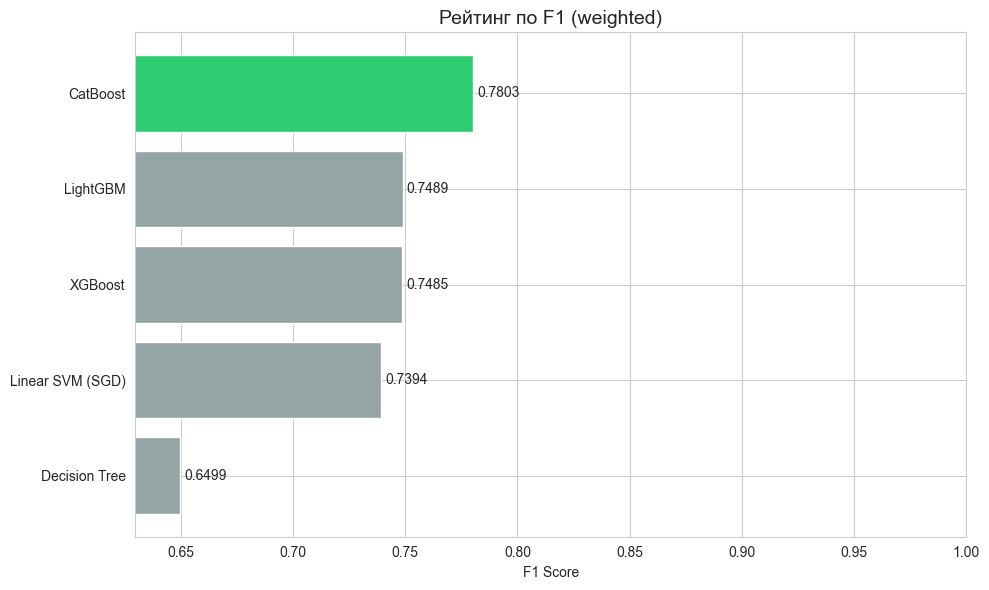

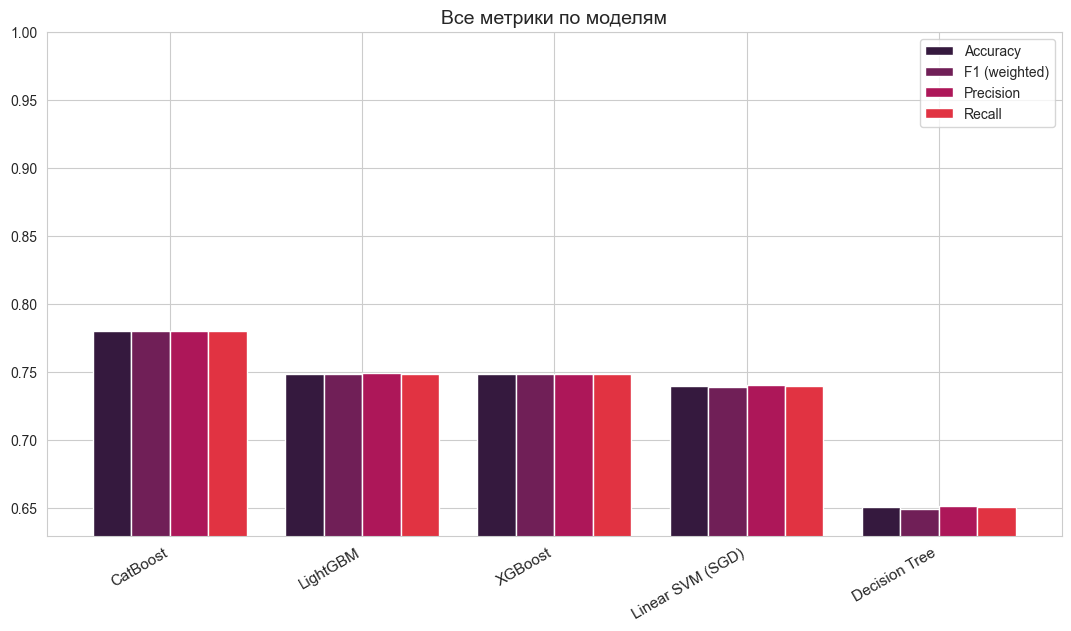

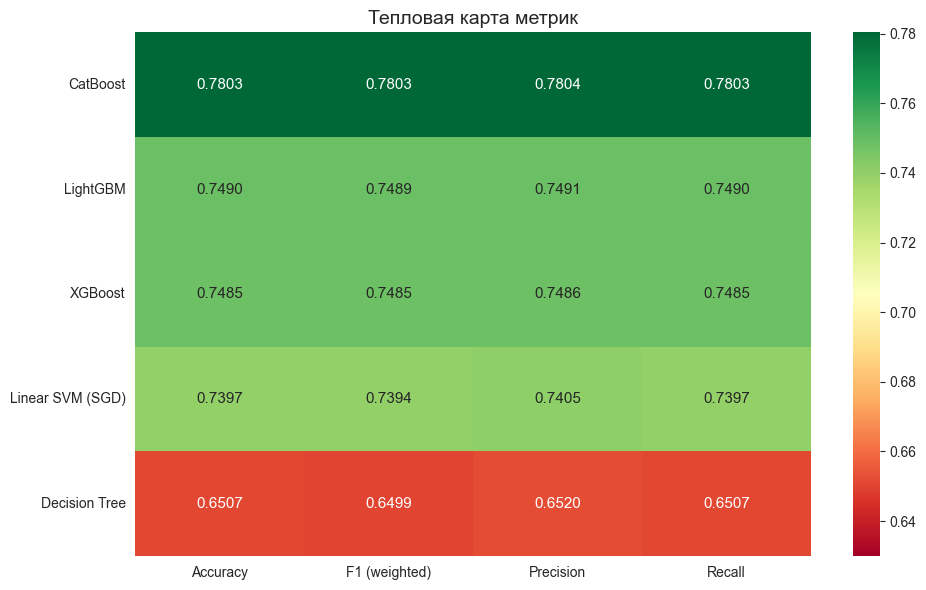

In [79]:
# Визуализация сравнения моделей

metrics = ['Accuracy', 'F1 (weighted)', 'Precision', 'Recall']
colors = ['#2ecc71' if i == 0 else '#95a5a6' for i in range(len(df_results))]

# --- График 1: Общий рейтинг по F1 ---
fig1, ax1 = plt.subplots(figsize=(10, 6))
bars = ax1.barh(df_results['Модель'], df_results['F1 (weighted)'].astype(float), color=colors)
ax1.set_xlim(df_results['F1 (weighted)'].astype(float).min() - 0.02, 1.0)
ax1.set_title('Рейтинг по F1 (weighted)', fontsize=14)
ax1.set_xlabel('F1 Score')
ax1.bar_label(bars, fmt='%.4f', padding=3)
ax1.invert_yaxis()
plt.tight_layout()
plt.show()

# --- График 2: Все метрики рядом ---
fig2, ax2 = plt.subplots(figsize=(14, 8)) 
x = np.arange(len(df_results))
width = 0.2
for i, metric in enumerate(metrics):
    ax2.bar(x + i * width, df_results[metric].astype(float), width, label=metric)
ax2.set_xticks(x + width * 1.5)
ax2.set_xticklabels(df_results['Модель'], rotation=30, ha='right', fontsize=11)
ax2.set_ylim(df_results[metrics].astype(float).min().min() - 0.02, 1.0)
ax2.set_title('Все метрики по моделям', fontsize=14)
ax2.legend(loc='upper right')
plt.subplots_adjust(bottom=0.25, right=0.85)
plt.show() 

# --- График 3: Тепловая карта метрик ---
fig3, ax3 = plt.subplots(figsize=(10, 6))
heatmap_data = df_results[metrics].astype(float)
sns.heatmap(
    heatmap_data,
    annot=True, fmt='.4f', cmap='RdYlGn',
    xticklabels=metrics,
    yticklabels=df_results['Модель'],
    vmin=heatmap_data.min().min() - 0.02,
    annot_kws={'size': 11},
    ax=ax3
)
ax3.set_title('Тепловая карта метрик', fontsize=14)
plt.tight_layout()
plt.show()

In [80]:
# Итоговый вывод

best_model = df_results.iloc[0]

print("=" * 50)
print("ИТОГОВЫЙ ВЫВОД")
print("=" * 50)
print(f"Лучшая модель:  {best_model['Модель']}")
print(f"Accuracy:       {best_model['Accuracy']}")
print(f"Precision:      {best_model['Precision']}")
print(f"Recall:         {best_model['Recall']}")
print(f"F1 (weighted):  {best_model['F1 (weighted)']}")
print("=" * 50)
print(f"Модель превзошла остальные по F1 (weighted) —")
print(f"метрике, учитывающей баланс Precision и Recall")
print(f"по обоим классам (Negative и Positive).")
print("=" * 50)

ИТОГОВЫЙ ВЫВОД
Лучшая модель:  CatBoost
Accuracy:       0.7803
Precision:      0.7804
Recall:         0.7803
F1 (weighted):  0.7803
Модель превзошла остальные по F1 (weighted) —
метрике, учитывающей баланс Precision и Recall
по обоим классам (Negative и Positive).
